## Clustering Wholesale Customers

This notebook explores the Wholesale customers dataset with clustering. I standardize the spending features, compare a few values of `k` with silhouette scores, fit k-means, and visualize the resulting segments with PCA.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

%matplotlib inline

data = pd.read_csv('Wholesale customers data.csv')
data.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [2]:
features = data.drop(columns=['Channel', 'Region'])

scaler = StandardScaler()
data_scaled = pd.DataFrame(scaler.fit_transform(features), columns=features.columns)
data_scaled.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,0.052933,0.523568,-0.041115,-0.589367,-0.043569,-0.066339
1,-0.391302,0.544458,0.170318,-0.270136,0.086407,0.089151
2,-0.447029,0.408538,-0.028157,-0.137536,0.133232,2.243293
3,0.100111,-0.624020,-0.392977,0.687144,-0.498588,0.093411
4,0.840239,-0.052396,-0.079356,0.173859,-0.231918,1.299347


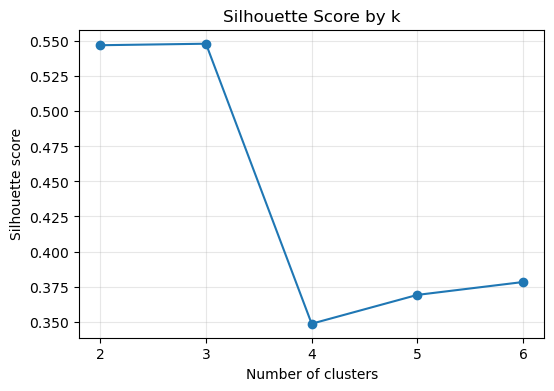

,k,silhouette_score
0,2,0.547215
1,3,0.548287
2,4,0.348471
3,5,0.369040
4,6,0.378229


In [3]:
scores = []
for k in range(2, 7):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(data_scaled)
    scores.append({'k': k, 'silhouette_score': silhouette_score(data_scaled, labels)})

scores_df = pd.DataFrame(scores)
plt.figure(figsize=(6, 4))
plt.plot(scores_df['k'], scores_df['silhouette_score'], marker='o')
plt.title('Silhouette Score by k')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette score')
plt.xticks(scores_df['k'])
plt.grid(True, alpha=0.3)
plt.show()

scores_df

### Fit k-means with 3 clusters

The silhouette scores suggest that 3 clusters is a reasonable choice: it keeps the solution interpretable while still separating the strongest spending patterns.

In [4]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
data['Cluster'] = kmeans.fit_predict(data_scaled)

data['Cluster'].value_counts().sort_index()

Cluster
0     45
1    393
2      2
Name: count, dtype: int64

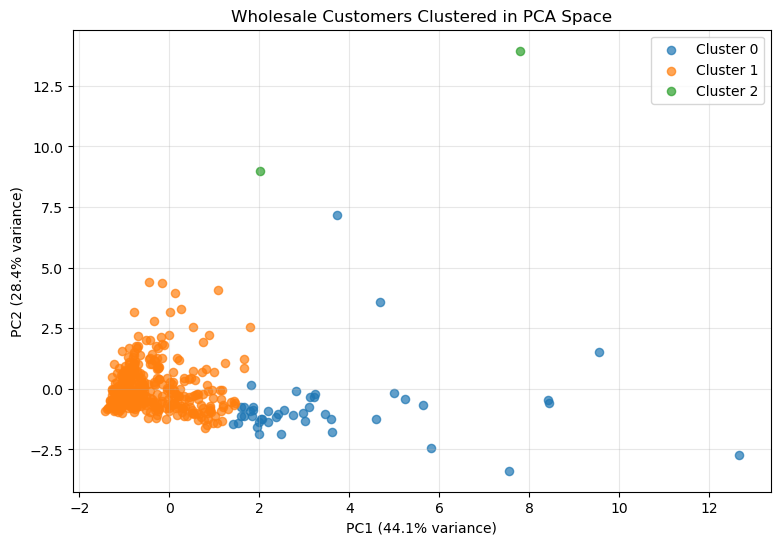

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Cluster,,,,,,
0,10440.9,19386.4,28656.1,2190.2,13327.8,2374.2
1,12062.9,4115.1,5535.0,2940.7,1696.2,1299.1
2,34782.0,30367.0,16898.0,48701.5,755.5,26776.0


In [5]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(data_scaled)
plot_df = pd.DataFrame(coords, columns=['PC1', 'PC2'])
plot_df['Cluster'] = data['Cluster'].astype(str)

plt.figure(figsize=(9, 6))
for cluster_id, group in plot_df.groupby('Cluster'):
    plt.scatter(group['PC1'], group['PC2'], label=f'Cluster {cluster_id}', alpha=0.7, s=35)

plt.title('Wholesale Customers Clustered in PCA Space')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

cluster_means = data.groupby('Cluster')[features.columns].mean().round(1)
cluster_means